# Quantitative metric plots

In [1]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pandas.errors import EmptyDataError, ParserError

%matplotlib inline


# =========================
# Paths
# =========================
EVAL_ROOT = Path(
    "/data/brussel/114/vsc11442/code/mlcast-ldcast/"
    "results/evaluation/test_2021_6hourly"
)

FIG_DIR = EVAL_ROOT / "figures_results"
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("EVAL_ROOT:", EVAL_ROOT)
print("FIG_DIR:", FIG_DIR)


# =========================
# Model display settings
# =========================
MODEL_ORDER = [
    "PySTEPS",
    "ConvGRU 10%",
    "ConvGRU full",
    "ConvGRU ensemble 10%",
    "ConvGRU ensemble full",
    "U-Net 10%",
    "U-Net full",
    "U-Net ensemble 10%",
    "U-Net ensemble full",
    "LDCast 10%",
    "LDCast full",
]


DIR_TO_LABEL = {
    "metrics_belgium_pysteps_full":
        "PySTEPS",

    "metrics_belgium_convgru_10pct":
        "ConvGRU 10%",
    "metrics_belgium_convgru_full":
        "ConvGRU full",

    "metrics_belgium_convgru_ens_10pct":
        "ConvGRU ensemble 10%",
    "metrics_belgium_convgru_ens_full":
        "ConvGRU ensemble full",

    "metrics_belgium_unet_10pct":
        "U-Net 10%",
    "metrics_belgium_unet_full":
        "U-Net full",

    "metrics_belgium_unet_ens_10pct":
        "U-Net ensemble 10%",
    "metrics_belgium_unet_ens_full":
        "U-Net ensemble full",

    "metrics_belgium_ldcast_10pct":
        "LDCast 10%",
    "metrics_belgium_ldcast_full":
        "LDCast full",
}


MODEL_NAME_CLEAN = {
    "pysteps": "PySTEPS",
    "convgru": "ConvGRU",
    "convgru_ens": "ConvGRU ensemble",
    "unet": "U-Net",
    "unet_ens": "U-Net ensemble",
    "ldcast": "LDCast",
}


LEAD_TICKS = [5, 20, 40, 60, 80, 100]

MODEL_FAMILIES = {
    "PySTEPS": "PySTEPS",

    "ConvGRU 10%": "ConvGRU",
    "ConvGRU full": "ConvGRU",

    "ConvGRU ensemble 10%": "ConvGRU ensemble",
    "ConvGRU ensemble full": "ConvGRU ensemble",

    "U-Net 10%": "U-Net",
    "U-Net full": "U-Net",

    "U-Net ensemble 10%": "U-Net ensemble",
    "U-Net ensemble full": "U-Net ensemble",

    "LDCast 10%": "LDCast",
    "LDCast full": "LDCast",
}

FAMILY_ORDER = [
    "PySTEPS",
    "ConvGRU",
    "ConvGRU ensemble",
    "U-Net",
    "U-Net ensemble",
    "LDCast",
]

FAMILY_MARKERS = {
    "PySTEPS": "o",
    "ConvGRU": "s",
    "ConvGRU ensemble": "^",
    "U-Net": "D",
    "U-Net ensemble": "v",
    "LDCast": "P",
}

_cmap = plt.get_cmap("tab10")
FAMILY_COLORS = {
    family: _cmap(i)
    for i, family in enumerate(FAMILY_ORDER)
}


def style_for(label):
    """
    Consistent model-family styling.

    Model family:
        colour + marker shape

    Training split:
        10%  -> dashed line + hollow marker
        full -> solid line + filled marker
    """
    label = str(label)
    family = MODEL_FAMILIES[label]
    color = FAMILY_COLORS[family]

    is_10pct = "10%" in label

    return {
        "color": color,
        "marker": FAMILY_MARKERS[family],

        # Make split distinction much clearer
        "linestyle": (0, (5, 2.5)) if is_10pct else "-",
        "linewidth": 1.8 if is_10pct else 2.2,

        # Do not put a marker on every 5-minute point
        "markevery": 2,
        "markersize": 5.5,

        # 10% = hollow; full = filled
        "markerfacecolor": "none" if is_10pct else color,
        "markeredgecolor": color,
        "markeredgewidth": 1.2,

        "alpha": 0.90 if is_10pct else 1.0,
    }
    
def clean_split(x):
    """Standardize split names."""
    x = str(x).strip().lower()

    if x in {"10pct", "10%", "10", "0.1"}:
        return "10%"

    if x == "full":
        return "full"

    return x


def infer_label_from_df_or_dir(df, metric_dir):
    """Infer a human-readable label without merging epoch variants."""
    dname = Path(metric_dir).name

    # First use explicitly defined folder labels.
    if dname in DIR_TO_LABEL:
        return DIR_TO_LABEL[dname]

    # Handle unforeseen epoch-labelled directories.
    epoch_match = re.search(r"_epoch(\d+)$", dname)
    epoch = epoch_match.group(1) if epoch_match else None

    if "model" in df.columns and "split" in df.columns and len(df) > 0:
        model_raw = str(df["model"].iloc[0]).strip()
        split = clean_split(df["split"].iloc[0])

        model_clean = MODEL_NAME_CLEAN.get(model_raw, model_raw)
        label = f"{model_clean} {split}"

        if epoch is not None:
            label += f" (epoch {epoch})"

        return label

    # Last-resort label inferred from the folder name.
    fallback = dname.removeprefix("metrics_")
    fallback = fallback.replace("10pct", "10%")
    fallback = fallback.replace("_", " ")

    return fallback


def find_metric_dirs(root):
    """Find metric directories containing at least one CSV file."""
    directories = sorted(
        p for p in root.glob("metrics*")
        if p.is_dir() and any(p.glob("*.csv"))
    )
    return directories


METRIC_DIRS = find_metric_dirs(EVAL_ROOT)

print("\nMetric folders found:")
for directory in METRIC_DIRS:
    print(" ", directory.name)


def csv_has_content(path):
    """Return False for zero-byte or whitespace-only files."""
    try:
        if path.stat().st_size == 0:
            return False

        # Reading a small prefix also catches files containing only whitespace.
        with path.open("r", encoding="utf-8", errors="replace") as handle:
            prefix = handle.read(4096)

        return bool(prefix.strip())

    except OSError as exc:
        print(f"Could not inspect {path}: {exc}")
        return False


def read_metric_csv(filename):
    """Load one metric CSV type from every available model folder."""
    tables = []

    print(f"\nLoading {filename}:")

    for directory in METRIC_DIRS:
        filepath = directory / filename

        if not filepath.exists():
            print(f"  Missing: {directory.name}/{filename}")
            continue

        if not csv_has_content(filepath):
            print(f"  Skipping empty: {filepath}")
            continue

        try:
            df = pd.read_csv(filepath)

        except EmptyDataError:
            print(f"  Skipping empty/unparseable: {filepath}")
            continue

        except ParserError as exc:
            print(f"  CSV parser error: {filepath}")
            print(f"    {exc}")
            continue

        except Exception as exc:
            print(f"  Failed to read: {filepath}")
            print(f"    {type(exc).__name__}: {exc}")
            continue

        if df.empty:
            print(f"  Skipping table with no rows: {filepath}")
            continue

        label = infer_label_from_df_or_dir(df, directory)

        df = df.copy()
        df["source_metric_dir"] = directory.name
        df["model_label"] = label

        tables.append(df)

        print(
            f"  Loaded: {directory.name}/{filename} "
            f"({len(df):,} rows) -> {label}"
        )

    if not tables:
        print(f"No non-empty {filename} files were loaded.")
        return pd.DataFrame()

    out = pd.concat(tables, ignore_index=True, sort=False)

    # Include unexpected labels after the preferred model order. This avoids
    # Pandas' warning about values not included in the categorical categories.
    labels_present = list(
        pd.unique(out["model_label"].dropna().astype(str))
    )

    preferred_categories = [
        label for label in MODEL_ORDER
        if label in labels_present
    ]

    unexpected_categories = [
        label for label in labels_present
        if label not in MODEL_ORDER
    ]

    if unexpected_categories:
        print(
            f"  Labels not listed in MODEL_ORDER for {filename}: "
            f"{unexpected_categories}"
        )

    categories = preferred_categories + unexpected_categories

    out["model_label"] = pd.Categorical(
        out["model_label"],
        categories=categories,
        ordered=True,
    )

    # Stable sorting keeps original row order within each model.
    out = (
        out.sort_values("model_label", kind="stable")
        .reset_index(drop=True)
    )

    return out

# =========================
# FINAL pooled/weighted tables for thesis plots
# =========================

det = read_metric_csv(
    "summary_deterministic_by_lead.csv"
)

cat = read_metric_csv(
    "summary_categorical_pooled_by_lead.csv"
)

prob = read_metric_csv(
    "summary_probabilistic_by_lead.csv"
)

fss = read_metric_csv(
    "summary_fss_pooled_by_lead.csv"
)

rank = read_metric_csv(
    "summary_rank_histograms_by_lead.csv"
)

reliability = read_metric_csv(
    "summary_reliability_weighted.csv"
)

coverage = read_metric_csv(
    "coverage_diagnostics.csv"
)

# Tables for overall numerical summaries
main_overall = read_metric_csv(
    "summary_main_metrics.csv"
)

cat_overall = read_metric_csv(
    "summary_categorical_pooled_overall.csv"
)

prob_overall = read_metric_csv(
    "summary_probabilistic_overall.csv"
)

fss_overall = read_metric_csv(
    "summary_fss_pooled_overall.csv"
)


print("\nLoaded shapes:")
print("deterministic:", det.shape, det.columns.tolist())
print("categorical:", cat.shape, cat.columns.tolist())
print("probabilistic:", prob.shape, prob.columns.tolist())
print("fss:", fss.shape, fss.columns.tolist())
print("rank_histograms:", rank.shape, rank.columns.tolist())

EVAL_ROOT: /data/brussel/114/vsc11442/code/mlcast-ldcast/results/evaluation/test_2021_6hourly
FIG_DIR: /data/brussel/114/vsc11442/code/mlcast-ldcast/results/evaluation/test_2021_6hourly/figures_results

Metric folders found:
  metrics_belgium_convgru_10pct
  metrics_belgium_convgru_ens_10pct
  metrics_belgium_convgru_ens_full
  metrics_belgium_convgru_full
  metrics_belgium_ldcast_10pct
  metrics_belgium_ldcast_full
  metrics_belgium_pysteps_full
  metrics_belgium_unet_10pct
  metrics_belgium_unet_ens_10pct
  metrics_belgium_unet_ens_full
  metrics_belgium_unet_full

Loading summary_deterministic_by_lead.csv:
  Loaded: metrics_belgium_convgru_10pct/summary_deterministic_by_lead.csv (20 rows) -> ConvGRU 10%
  Loaded: metrics_belgium_convgru_ens_10pct/summary_deterministic_by_lead.csv (20 rows) -> ConvGRU ensemble 10%
  Loaded: metrics_belgium_convgru_ens_full/summary_deterministic_by_lead.csv (20 rows) -> ConvGRU ensemble full
  Loaded: metrics_belgium_convgru_full/summary_deterministic

In [2]:
def first_existing_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

def add_lead_minutes(df):
    df = df.copy()

    lead_min_col = first_existing_col(df, ["lead_min", "lead_minutes", "lead_time_min", "lead_time_minutes"])
    if lead_min_col is not None:
        df["lead_min_plot"] = df[lead_min_col].astype(float)
        return df

    lead_col = first_existing_col(df, ["lead", "lead_idx", "lead_index", "forecast_step", "step"])
    if lead_col is None:
        raise KeyError(f"No lead column found. Columns: {df.columns.tolist()}")

    lead = df[lead_col].astype(float)

    # If stored as 0..19, convert to +5..+100.
    # If stored as 1..20, convert to +5..+100.
    if lead.min() == 0 and lead.max() <= 19:
        df["lead_min_plot"] = (lead + 1) * 5
    elif lead.min() >= 1 and lead.max() <= 20:
        df["lead_min_plot"] = lead * 5
    else:
        df["lead_min_plot"] = lead

    return df

def add_threshold_col(df):
    """Create a standardized numeric threshold column."""
    df = df.copy()

    threshold_candidates = [
        "threshold",
        "threshold_mm_h",
        "threshold_mmh",
        "threshold_mmph",
        "threshold_mm_per_h",
        "rain_threshold",
        "rain_threshold_mm_h",
        "rainrate_threshold",
        "rain_rate_threshold",
        "precip_threshold",
        "thr",
        "q",
    ]

    th_col = first_existing_col(df, threshold_candidates)

    # Fallback: find any column whose name contains "threshold"
    if th_col is None:
        possible = [
            col for col in df.columns
            if "threshold" in str(col).lower()
        ]

        if len(possible) == 1:
            th_col = possible[0]
        elif len(possible) > 1:
            raise KeyError(
                "Multiple possible threshold columns found: "
                f"{possible}. Select the correct one explicitly."
            )

    if th_col is None:
        raise KeyError(
            "No threshold column could be identified.\n"
            f"Available columns: {df.columns.tolist()}"
        )

    df["threshold_plot"] = pd.to_numeric(
        df[th_col],
        errors="coerce",
    )

    print(f"Using threshold column: {th_col!r}")
    print(
        "Available thresholds:",
        sorted(df["threshold_plot"].dropna().unique()),
    )

    return df

def add_window_col(df):
    """Create a standardized numeric neighbourhood/window column."""
    df = df.copy()

    window_candidates = [
        "window",
        "window_size",
        "window_size_px",
        "window_px",
        "neighborhood",
        "neighbourhood",
        "neighborhood_size",
        "neighbourhood_size",
        "neighborhood_px",
        "neighbourhood_px",
        "scale",
        "scale_px",
        "win",
    ]

    w_col = first_existing_col(df, window_candidates)

    # Fallback: search column names for likely window terms
    if w_col is None:
        possible = [
            col for col in df.columns
            if any(
                term in str(col).lower()
                for term in [
                    "window",
                    "neighborhood",
                    "neighbourhood",
                    "scale",
                ]
            )
        ]

        if len(possible) == 1:
            w_col = possible[0]
        elif len(possible) > 1:
            raise KeyError(
                "Multiple possible neighbourhood columns found: "
                f"{possible}"
            )

    if w_col is None:
        raise KeyError(
            "No window/neighbourhood column could be identified.\n"
            f"Available columns: {df.columns.tolist()}"
        )

    df["window_plot"] = pd.to_numeric(
        df[w_col],
        errors="coerce",
    )

    print(f"Using window column: {w_col!r}")
    print(
        "Available windows:",
        sorted(df["window_plot"].dropna().unique()),
    )

    return df

def metric_col(df, names):
    c = first_existing_col(df, names)
    if c is None:
        raise KeyError(f"None of {names} found. Columns: {df.columns.tolist()}")
    return c

def model_sort_key(label):
    try:
        return MODEL_ORDER.index(str(label))
    except ValueError:
        return 999

def ordered_model_labels(df):
    labels = [str(x) for x in df["model_label"].dropna().unique()]
    return sorted(labels, key=model_sort_key)

def savefig(name):
    out = FIG_DIR / name
    plt.savefig(out, dpi=300, bbox_inches="tight")
    print("Saved:", out)

In [3]:
METRIC_ALIASES = {
    "mae": [
        "mae",
        "mean_absolute_error",
    ],
    "rmse": [
        "rmse",
        "root_mean_squared_error",
    ],
    "bias": [
        "bias",
        "me",
        "mean_error",
        "mean_signed_error",
    ],
}


def resolve_metric_col(df, metric_name):
    """Find the actual CSV column corresponding to a requested metric."""
    metric_key = metric_name.strip().lower()

    candidates = METRIC_ALIASES.get(
        metric_key,
        [metric_name, metric_name.lower(), metric_name.upper()],
    )

    column = first_existing_col(df, candidates)

    if column is None:
        raise KeyError(
            f"Could not find metric '{metric_name}'.\n"
            f"Tried columns: {candidates}\n"
            f"Available columns: {df.columns.tolist()}"
        )

    return column


def plot_deterministic_by_lead(
    metric_name,
    ylabel,
    filename,
    title=None,
):
    df = add_lead_minutes(det)
    ycol = resolve_metric_col(df, metric_name)

    print(f"Plotting {metric_name!r} using column {ycol!r}")

    g = (
        df.groupby(
            ["model_label", "lead_min_plot"],
            observed=True,
        )[ycol]
        .mean()
        .reset_index()
    )

    fig, ax = plt.subplots(figsize=(9, 5.2))

    for label in ordered_model_labels(g):
        gg = (
            g[g["model_label"].astype(str) == label]
            .sort_values("lead_min_plot")
        )

        if gg.empty:
            continue

        ax.plot(
            gg["lead_min_plot"],
            gg[ycol],
            label=label,
            **style_for(label),
        )

    if metric_name.lower() == "bias":
        ax.axhline(
            0,
            linewidth=1.2,
            linestyle="--",
        )

    ax.set_xlabel("Lead time (minutes)")
    ax.set_ylabel(ylabel)
    ax.set_title(title or f"{ylabel} by lead time")
    ax.set_xticks(LEAD_TICKS)
    ax.set_xlim(5, 100)
    ax.grid(True, alpha=0.3)
    ax.legend(
        loc="upper center",
        bbox_to_anchor=(0.5, -0.16),
        ncol=4,
        fontsize=8,
    )
    
    fig.subplots_adjust(bottom=0.27)
    savefig(filename)
    plt.show()

Plotting 'mae' using column 'mae'
Saved: /data/brussel/114/vsc11442/code/mlcast-ldcast/results/evaluation/test_2021_6hourly/figures_results/mae_by_lead.png


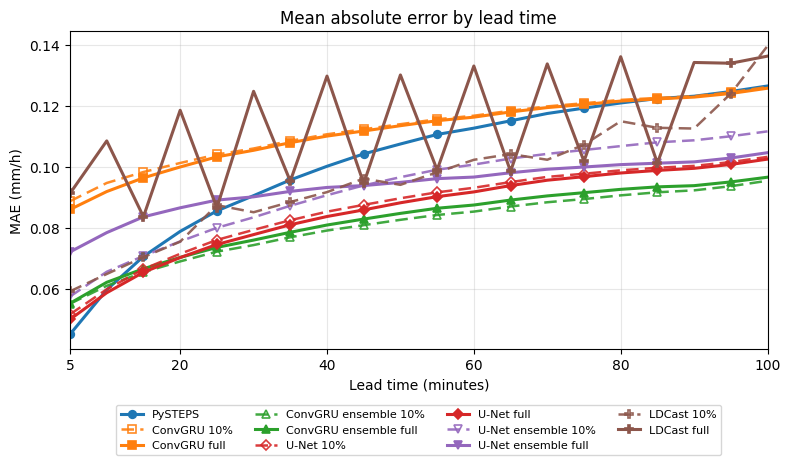

Plotting 'rmse' using column 'rmse'
Saved: /data/brussel/114/vsc11442/code/mlcast-ldcast/results/evaluation/test_2021_6hourly/figures_results/rmse_by_lead.png


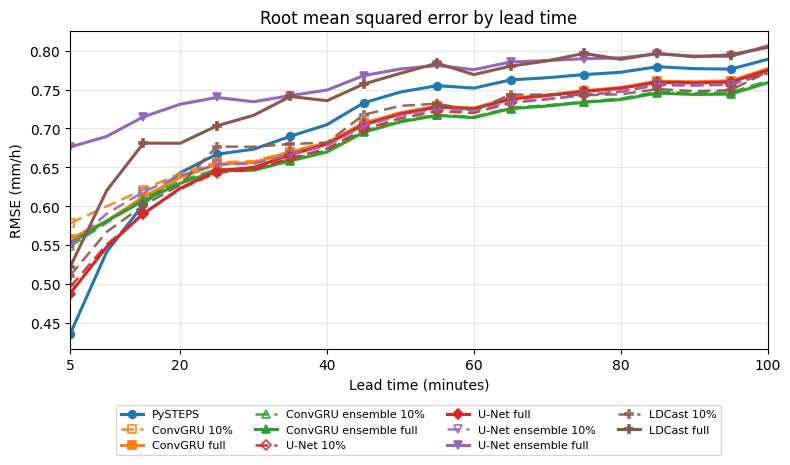

Plotting 'bias' using column 'me'
Saved: /data/brussel/114/vsc11442/code/mlcast-ldcast/results/evaluation/test_2021_6hourly/figures_results/bias_by_lead.png


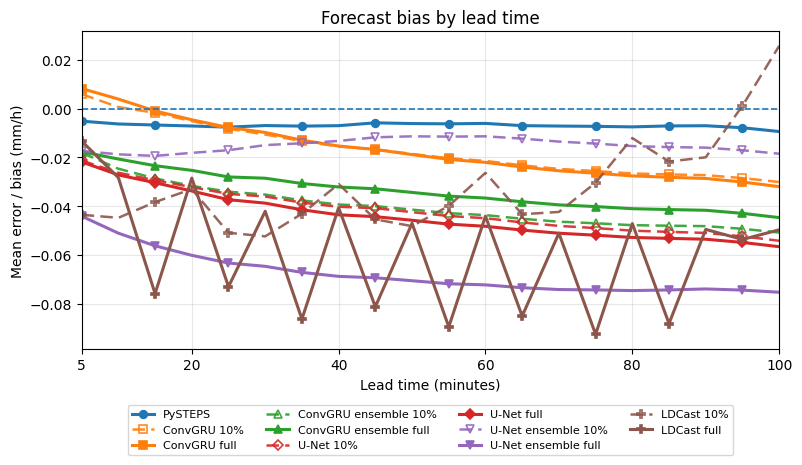

Plotting 'mae_obs_ge_0p25' using column 'mae_obs_ge_0p25'
Saved: /data/brussel/114/vsc11442/code/mlcast-ldcast/results/evaluation/test_2021_6hourly/figures_results/mae_rain_ge_0p25_by_lead.png


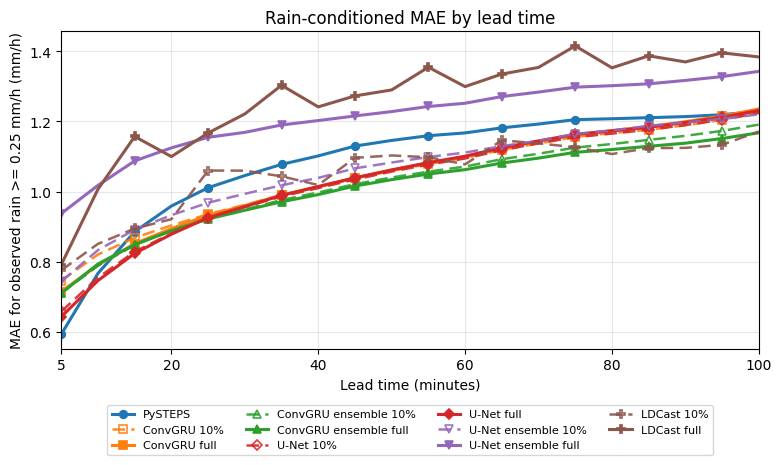

In [4]:
plot_deterministic_by_lead(
    "mae",
    "MAE (mm/h)",
    "mae_by_lead.png",
    "Mean absolute error by lead time",
)

plot_deterministic_by_lead(
    "rmse",
    "RMSE (mm/h)",
    "rmse_by_lead.png",
    "Root mean squared error by lead time",
)

plot_deterministic_by_lead(
    "bias",
    "Mean error / bias (mm/h)",
    "bias_by_lead.png",
    "Forecast bias by lead time",
)

plot_deterministic_by_lead(
    "mae_obs_ge_0p25",
    "MAE for observed rain >= 0.25 mm/h (mm/h)",
    "mae_rain_ge_0p25_by_lead.png",
    "Rain-conditioned MAE by lead time",
)

Using threshold column: 'threshold_mm_h'
Available thresholds: [np.float64(0.1), np.float64(0.5), np.float64(1.0), np.float64(5.0), np.float64(30.0)]
Saved: /data/brussel/114/vsc11442/code/mlcast-ldcast/results/evaluation/test_2021_6hourly/figures_results/csi_by_lead.png


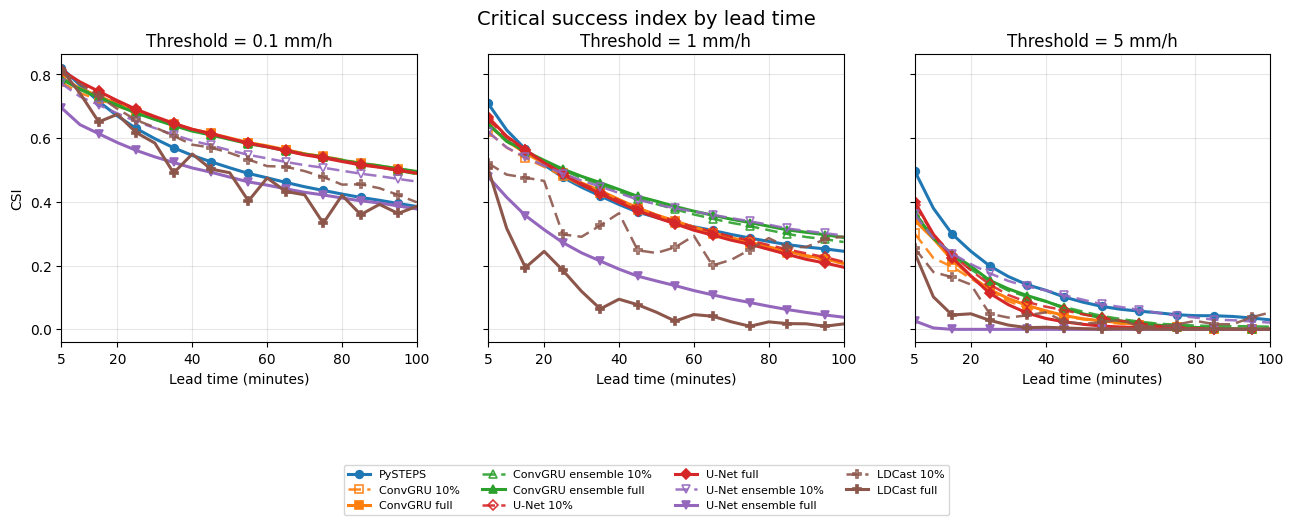

In [5]:
SELECTED_CSI_THRESHOLDS = [0.1, 1.0, 5.0]

def plot_csi_by_lead(filename="csi_by_lead.png"):
    df = add_lead_minutes(add_threshold_col(cat))
    csi_col = metric_col(df, ["csi", "CSI"])

    if "threshold_plot" not in df.columns:
        raise KeyError("No threshold column found in categorical.csv")

    available = sorted(df["threshold_plot"].dropna().unique())
    thresholds = [t for t in SELECTED_CSI_THRESHOLDS if any(np.isclose(t, available))]

    if not thresholds:
        thresholds = available[:3]

    fig, axes = plt.subplots(
        1,
        len(thresholds),
        figsize=(5.2 * len(thresholds), 4.5),
        sharey=True,
    )

    if len(thresholds) == 1:
        axes = [axes]

    for ax, th in zip(axes, thresholds):
        dth = df[np.isclose(df["threshold_plot"], th)].copy()

        g = (
            dth.groupby(["model_label", "lead_min_plot"], observed=True)[csi_col]
            .mean()
            .reset_index()
        )

        for label in ordered_model_labels(g):
            gg = g[g["model_label"].astype(str) == label].sort_values("lead_min_plot")
            if gg.empty:
                continue
            ax.plot(
                gg["lead_min_plot"],
                gg[csi_col],
                label=label,
                **style_for(label),
            )

        ax.set_title(f"Threshold = {th:g} mm/h")
        ax.set_xlabel("Lead time (minutes)")
        ax.set_xticks(LEAD_TICKS)
        ax.set_xlim(5, 100)
        ax.grid(True, alpha=0.3)

    axes[0].set_ylabel("CSI")
    
    handles, labels = axes[0].get_legend_handles_labels()
    
    fig.legend(
        handles,
        labels,
        loc="upper center",
        bbox_to_anchor=(0.5, -0.02),
        ncol=4,
        fontsize=8,
    )
    
    fig.suptitle(
        "Critical success index by lead time",
        fontsize=14,
    )
    
    fig.subplots_adjust(bottom=0.24)
    
    savefig(filename)
    plt.show()

plot_csi_by_lead()

Using threshold column: 'threshold_mm_h'
Available thresholds: [np.float64(0.1), np.float64(0.5), np.float64(1.0), np.float64(5.0), np.float64(30.0)]
Saved: /data/brussel/114/vsc11442/code/mlcast-ldcast/results/evaluation/test_2021_6hourly/figures_results/csi_30mm_by_lead.png


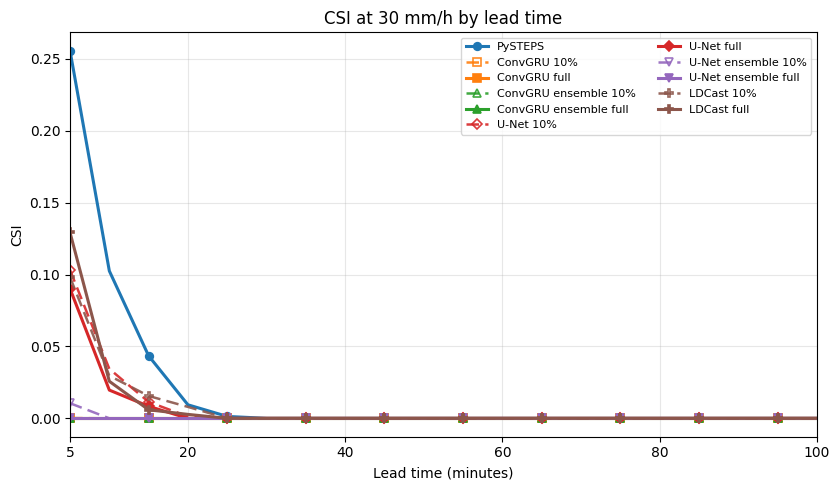

In [6]:
def plot_csi_30mm(
    filename="csi_30mm_by_lead.png"
):
    df = add_lead_minutes(
        add_threshold_col(cat)
    )

    df = df[
        np.isclose(
            df["threshold_plot"],
            30.0,
        )
    ].copy()

    fig, ax = plt.subplots(figsize=(8.5, 5))

    for label in ordered_model_labels(df):

        gg = (
            df[
                df["model_label"].astype(str)
                == label
            ]
            .sort_values("lead_min_plot")
        )

        ax.plot(
            gg["lead_min_plot"],
            gg["csi"],
            label=label,
            **style_for(label),
        )

    ax.set_xlabel("Lead time (minutes)")
    ax.set_ylabel("CSI")
    ax.set_title(
        "CSI at 30 mm/h by lead time"
    )
    ax.set_xticks(LEAD_TICKS)
    ax.set_xlim(5, 100)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8, ncol=2)

    fig.tight_layout()
    savefig(filename)
    plt.show()


plot_csi_30mm()

In [7]:
def make_csi_threshold_table(threshold=1.0):
    df = add_threshold_col(cat_overall)

    dth = df[
        np.isclose(
            df["threshold_plot"],
            threshold,
        )
    ].copy()

    cols = {
        "CSI": metric_col(dth, ["csi", "CSI"]),
        "POD": metric_col(dth, ["pod", "POD"]),
        "FAR": metric_col(dth, ["far", "FAR"]),
    }

    rows = []

    for label in ordered_model_labels(dth):
        gg = dth[
            dth["model_label"].astype(str)
            == label
        ]

        if gg.empty:
            continue

        row = gg.iloc[0]

        rows.append({
            "Model": label,
            "CSI": float(row[cols["CSI"]]),
            "POD": float(row[cols["POD"]]),
            "FAR": float(row[cols["FAR"]]),
        })

    out = pd.DataFrame(rows)

    for c in ["CSI", "POD", "FAR"]:
        out[c] = out[c].map(
            lambda x: f"{x:.4f}"
        )

    return out


csi_table_1mm = make_csi_threshold_table(1.0)

display(csi_table_1mm)
print(
    csi_table_1mm.to_latex(
        index=False,
        escape=False,
    )
)

Using threshold column: 'threshold_mm_h'
Available thresholds: [np.float64(0.1), np.float64(0.5), np.float64(1.0), np.float64(5.0), np.float64(30.0)]


,Model,CSI,POD,FAR
0,PySTEPS,0.3768,0.5605,0.4651
1,ConvGRU 10%,0.3721,0.4260,0.2540
2,ConvGRU full,0.3797,0.4370,0.2567
3,ConvGRU ensemble 10%,0.4090,0.5017,0.3112
4,ConvGRU ensemble full,0.4169,0.5300,0.3386
5,U-Net 10%,0.3826,0.4370,0.2454
6,U-Net full,0.3752,0.4255,0.2397
7,U-Net ensemble 10%,0.4049,0.5885,0.4352
8,U-Net ensemble full,0.1886,0.2038,0.2830
9,LDCast 10%,0.3117,0.3957,0.4052


\begin{tabular}{llll}
\toprule
Model & CSI & POD & FAR \\
\midrule
PySTEPS & 0.3768 & 0.5605 & 0.4651 \\
ConvGRU 10% & 0.3721 & 0.4260 & 0.2540 \\
ConvGRU full & 0.3797 & 0.4370 & 0.2567 \\
ConvGRU ensemble 10% & 0.4090 & 0.5017 & 0.3112 \\
ConvGRU ensemble full & 0.4169 & 0.5300 & 0.3386 \\
U-Net 10% & 0.3826 & 0.4370 & 0.2454 \\
U-Net full & 0.3752 & 0.4255 & 0.2397 \\
U-Net ensemble 10% & 0.4049 & 0.5885 & 0.4352 \\
U-Net ensemble full & 0.1886 & 0.2038 & 0.2830 \\
LDCast 10% & 0.3117 & 0.3957 & 0.4052 \\
LDCast full & 0.1070 & 0.1097 & 0.1878 \\
\bottomrule
\end{tabular}



Saved: /data/brussel/114/vsc11442/code/mlcast-ldcast/results/evaluation/test_2021_6hourly/figures_results/crps_by_lead.png


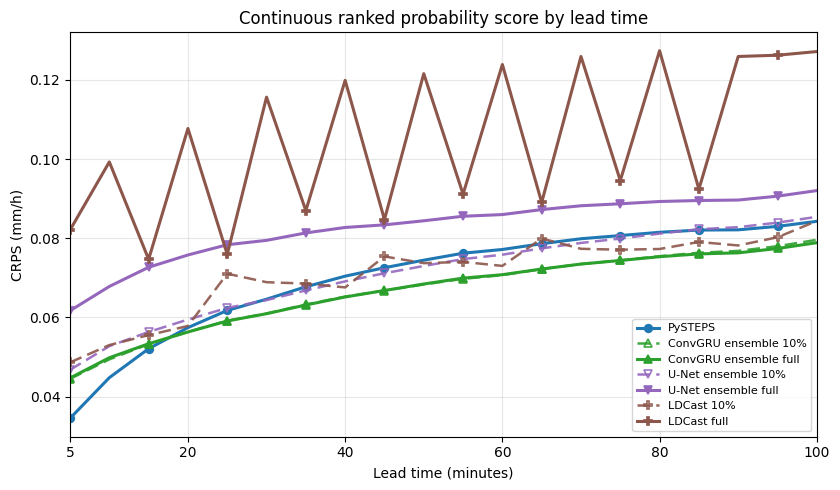

In [8]:
def plot_crps_by_lead(filename="crps_by_lead.png"):
    df = add_lead_minutes(prob)

    if "metric" not in df.columns or "value" not in df.columns:
        raise KeyError(
            "Expected long-format columns 'metric' and 'value'. "
            f"Available columns: {df.columns.tolist()}"
        )

    # Keep only CRPS rows
    df = df[
        df["metric"]
        .astype(str)
        .str.strip()
        .str.lower()
        .eq("crps")
    ].copy()

    if df.empty:
        raise ValueError(
            "No CRPS rows were found. Available metric names: "
            f"{sorted(prob['metric'].dropna().astype(str).unique())}"
        )

    df["value"] = pd.to_numeric(df["value"], errors="coerce")
    df = df.dropna(subset=["value", "lead_min_plot", "model_label"])

    g = (
        df.groupby(
            ["model_label", "lead_min_plot"],
            observed=True,
        )["value"]
        .mean()
        .reset_index()
    )

    fig, ax = plt.subplots(figsize=(8.5, 5))

    for label in ordered_model_labels(g):
        gg = (
            g[g["model_label"].astype(str) == label]
            .sort_values("lead_min_plot")
        )

        if gg.empty:
            continue

        ax.plot(
            gg["lead_min_plot"],
            gg["value"],
            label=label,
            **style_for(label),
        )

    ax.set_xlabel("Lead time (minutes)")
    ax.set_ylabel("CRPS (mm/h)")
    ax.set_title("Continuous ranked probability score by lead time")
    ax.set_xticks(LEAD_TICKS)
    ax.set_xlim(5, 100)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

    fig.tight_layout()
    savefig(filename)
    plt.show()


plot_crps_by_lead()

Using threshold column: 'threshold_mm_h'
Available thresholds: [np.float64(0.1), np.float64(0.25), np.float64(0.5), np.float64(1.0), np.float64(5.0), np.float64(30.0)]
Saved: /data/brussel/114/vsc11442/code/mlcast-ldcast/results/evaluation/test_2021_6hourly/figures_results/brier_by_lead.png


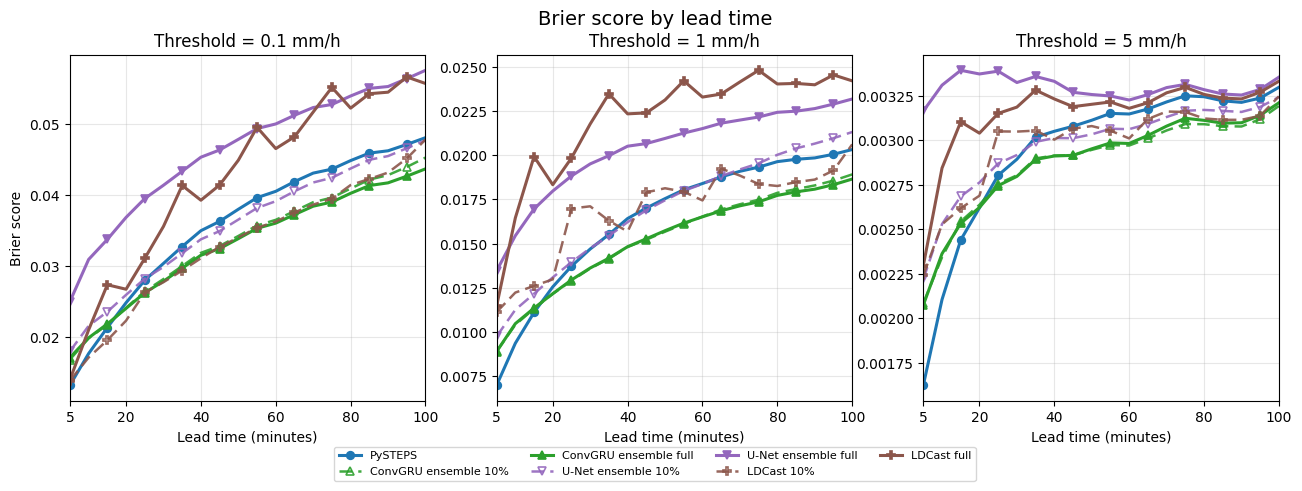

In [9]:
SELECTED_BRIER_THRESHOLDS = [0.1, 1.0, 5.0]


def plot_brier_by_lead(filename="brier_by_lead.png"):
    df = add_lead_minutes(add_threshold_col(prob))

    if "metric" not in df.columns or "value" not in df.columns:
        raise KeyError(
            "Expected long-format columns 'metric' and 'value'. "
            f"Available columns: {df.columns.tolist()}"
        )

    # Normalize metric names and keep only Brier-score rows
    metric_normalized = (
        df["metric"]
        .astype(str)
        .str.strip()
        .str.lower()
        .str.replace("-", "_", regex=False)
        .str.replace(" ", "_", regex=False)
    )

    brier_names = {
        "brier",
        "brier_score",
        "brierscore",
        "bs",
    }

    df = df[metric_normalized.isin(brier_names)].copy()

    if df.empty:
        raise ValueError(
            "No Brier-score rows were found. Available metric names: "
            f"{sorted(prob['metric'].dropna().astype(str).unique())}"
        )

    df["value"] = pd.to_numeric(df["value"], errors="coerce")
    df = df.dropna(
        subset=[
            "value",
            "threshold_plot",
            "lead_min_plot",
            "model_label",
        ]
    )

    available = sorted(df["threshold_plot"].unique())

    thresholds = [
        threshold
        for threshold in SELECTED_BRIER_THRESHOLDS
        if np.any(np.isclose(available, threshold))
    ]

    if not thresholds:
        thresholds = available[:3]
        print(
            "Requested thresholds were unavailable. "
            f"Using: {thresholds}"
        )

    if not thresholds:
        raise ValueError(
            "No valid Brier-score thresholds were found."
        )

    fig, axes = plt.subplots(
        1,
        len(thresholds),
        figsize=(5.2 * len(thresholds), 4.5),
        sharey=False,
    )

    if len(thresholds) == 1:
        axes = [axes]

    for ax, threshold in zip(axes, thresholds):
        dth = df[
            np.isclose(
                df["threshold_plot"],
                threshold,
            )
        ].copy()

        g = (
            dth.groupby(
                ["model_label", "lead_min_plot"],
                observed=True,
            )["value"]
            .mean()
            .reset_index()
        )

        for label in ordered_model_labels(g):
            gg = (
                g[g["model_label"].astype(str) == label]
                .sort_values("lead_min_plot")
            )

            if gg.empty:
                continue

            ax.plot(
                gg["lead_min_plot"],
                gg["value"],
                label=label,
                **style_for(label),
            )

        ax.set_title(f"Threshold = {threshold:g} mm/h")
        ax.set_xlabel("Lead time (minutes)")
        ax.set_xticks(LEAD_TICKS)
        ax.set_xlim(5, 100)
        ax.grid(True, alpha=0.3)

    axes[0].set_ylabel("Brier score")

    # One shared legend
    handles, labels = axes[-1].get_legend_handles_labels()

    fig.legend(
        handles,
        labels,
        loc="lower center",
        bbox_to_anchor=(0.5, -0.08),
        ncol=4,
        fontsize=8,
    )

    fig.suptitle("Brier score by lead time", fontsize=14)

    savefig(filename)
    plt.show()


plot_brier_by_lead()

Saved: /data/brussel/114/vsc11442/code/mlcast-ldcast/results/evaluation/test_2021_6hourly/figures_results/crps_rain_ge_0p25_by_lead.png


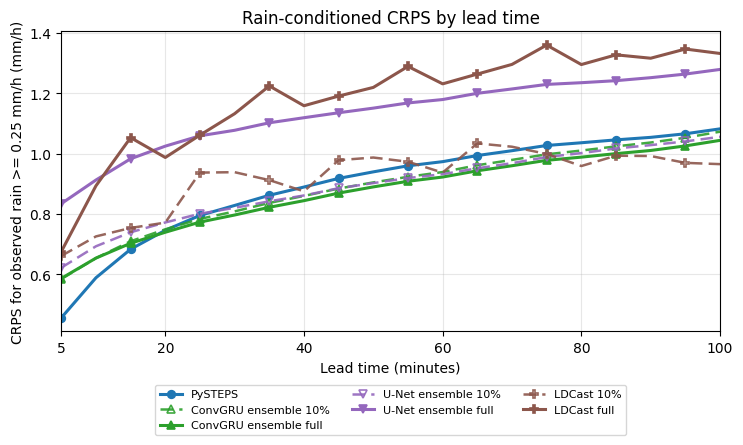

In [10]:
def plot_crps_rain_by_lead(
    filename="crps_rain_ge_0p25_by_lead.png"
):
    df = add_lead_minutes(prob)

    df = df[
        df["metric"]
        .astype(str)
        .str.lower()
        .eq("crps_obs_ge_0p25")
    ].copy()

    fig, ax = plt.subplots(figsize=(8.5, 5))

    for label in ordered_model_labels(df):

        gg = (
            df[
                df["model_label"].astype(str)
                == label
            ]
            .sort_values("lead_min_plot")
        )

        ax.plot(
            gg["lead_min_plot"],
            gg["value"],
            label=label,
            **style_for(label),
        )

    ax.set_xlabel("Lead time (minutes)")
    ax.set_ylabel(
        "CRPS for observed rain >= 0.25 mm/h (mm/h)"
    )
    ax.set_title("Rain-conditioned CRPS by lead time")
    ax.set_xticks(LEAD_TICKS)
    ax.set_xlim(5, 100)
    ax.grid(alpha=0.3)
    ax.legend(
        loc="upper center",
        bbox_to_anchor=(0.5, -0.16),
        ncol=3,
        fontsize=8,
    )
    
    fig.subplots_adjust(bottom=0.28)
    
    savefig(filename)
    plt.show()


plot_crps_rain_by_lead()


Rank histogram +5 min, X_min=0.1 mm/h
  PySTEPS: n_members=[np.int64(20)]
  ConvGRU ensemble 10%: n_members=[np.int64(20)]
  ConvGRU ensemble full: n_members=[np.int64(20)]
  U-Net ensemble 10%: n_members=[np.int64(20)]
  U-Net ensemble full: n_members=[np.int64(20)]
  LDCast 10%: n_members=[np.int64(20)]
  LDCast full: n_members=[np.int64(20)]
Saved: /data/brussel/114/vsc11442/code/mlcast-ldcast/results/evaluation/test_2021_6hourly/figures_results/rank_histograms_xmin0p1_lead005.png


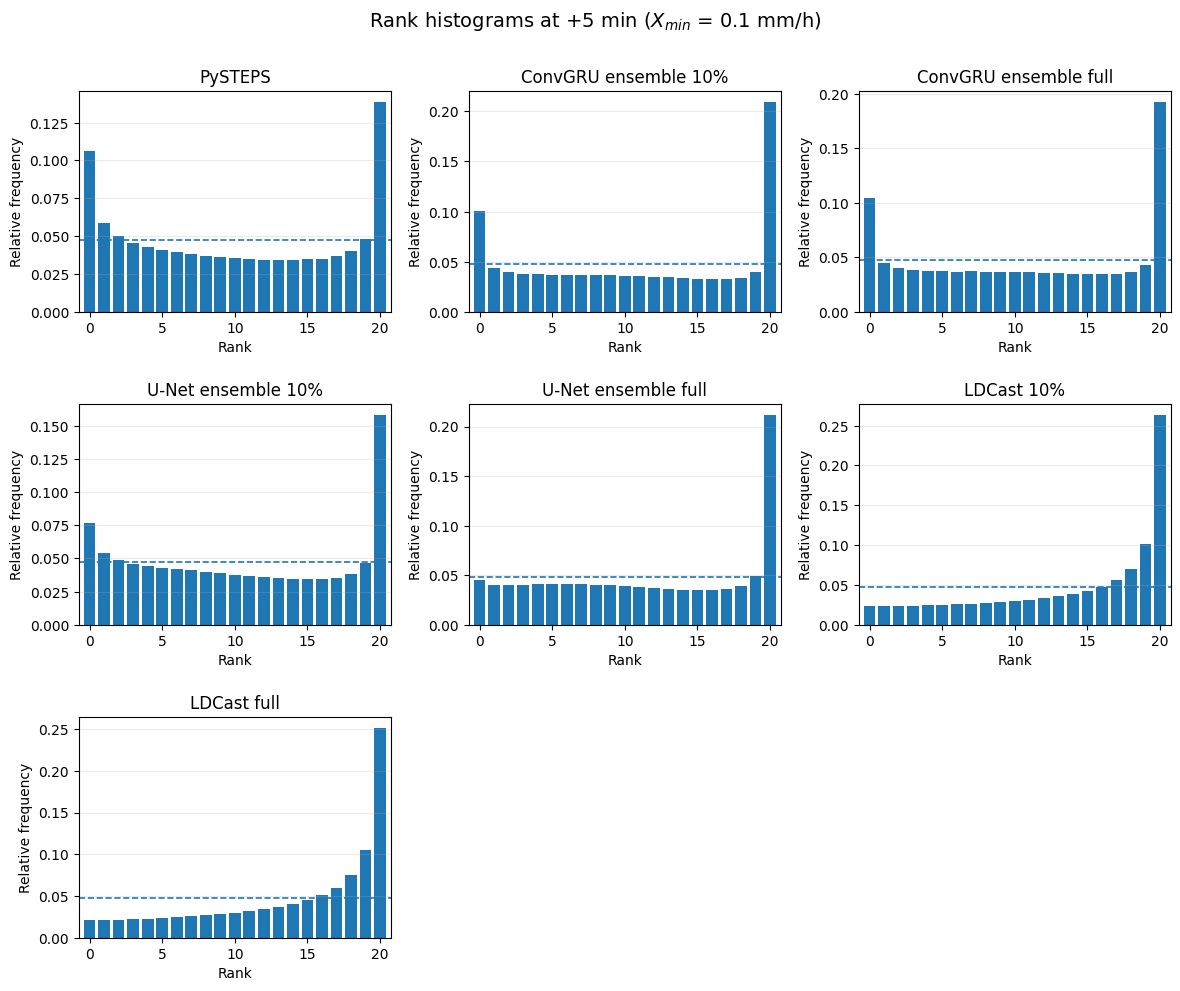


Rank histogram +50 min, X_min=0.1 mm/h
  PySTEPS: n_members=[np.int64(20)]
  ConvGRU ensemble 10%: n_members=[np.int64(20)]
  ConvGRU ensemble full: n_members=[np.int64(20)]
  U-Net ensemble 10%: n_members=[np.int64(20)]
  U-Net ensemble full: n_members=[np.int64(20)]
  LDCast 10%: n_members=[np.int64(20)]
  LDCast full: n_members=[np.int64(20)]
Saved: /data/brussel/114/vsc11442/code/mlcast-ldcast/results/evaluation/test_2021_6hourly/figures_results/rank_histograms_xmin0p1_lead050.png


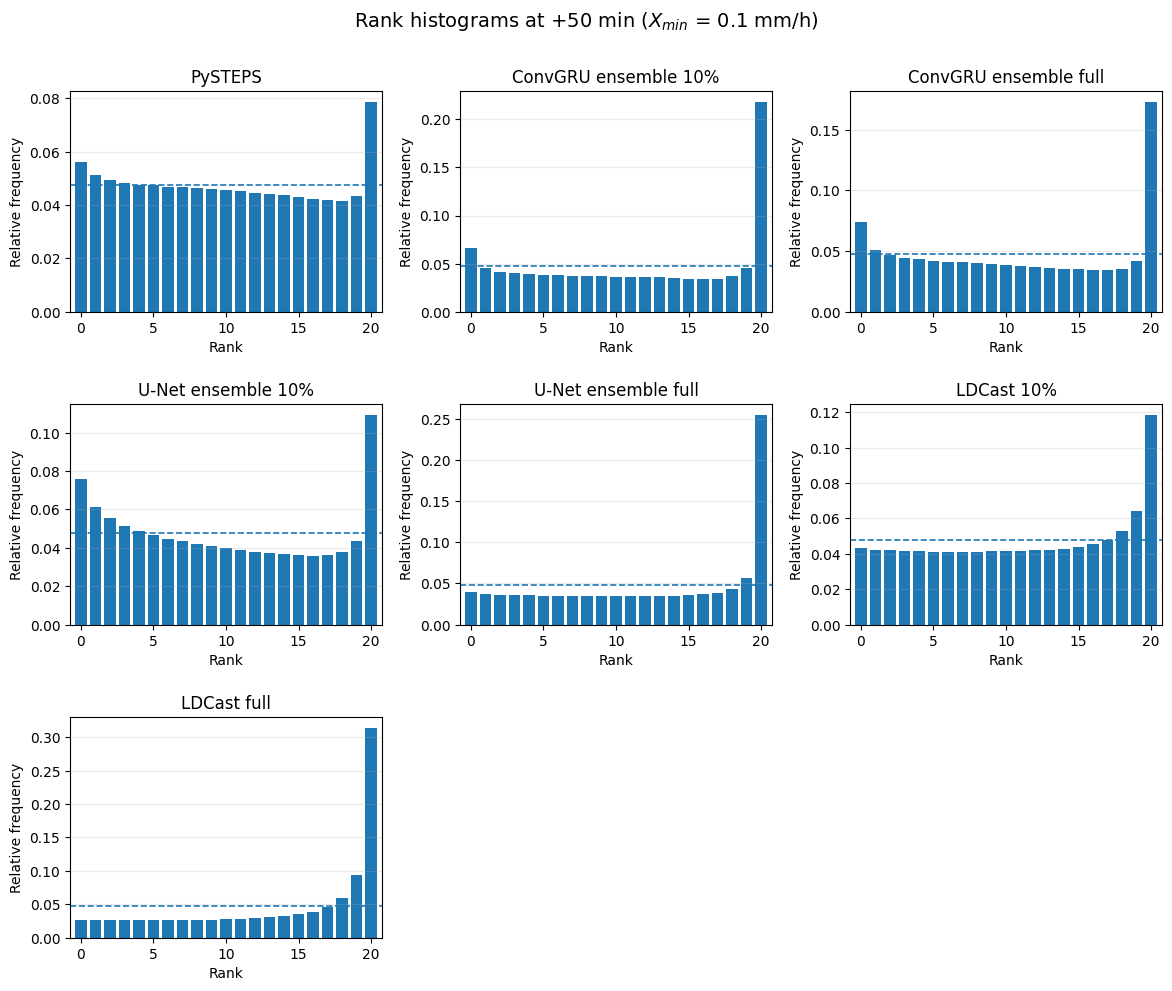


Rank histogram +100 min, X_min=0.1 mm/h
  PySTEPS: n_members=[np.int64(20)]
  ConvGRU ensemble 10%: n_members=[np.int64(20)]
  ConvGRU ensemble full: n_members=[np.int64(20)]
  U-Net ensemble 10%: n_members=[np.int64(20)]
  U-Net ensemble full: n_members=[np.int64(20)]
  LDCast 10%: n_members=[np.int64(20)]
  LDCast full: n_members=[np.int64(20)]
Saved: /data/brussel/114/vsc11442/code/mlcast-ldcast/results/evaluation/test_2021_6hourly/figures_results/rank_histograms_xmin0p1_lead100.png


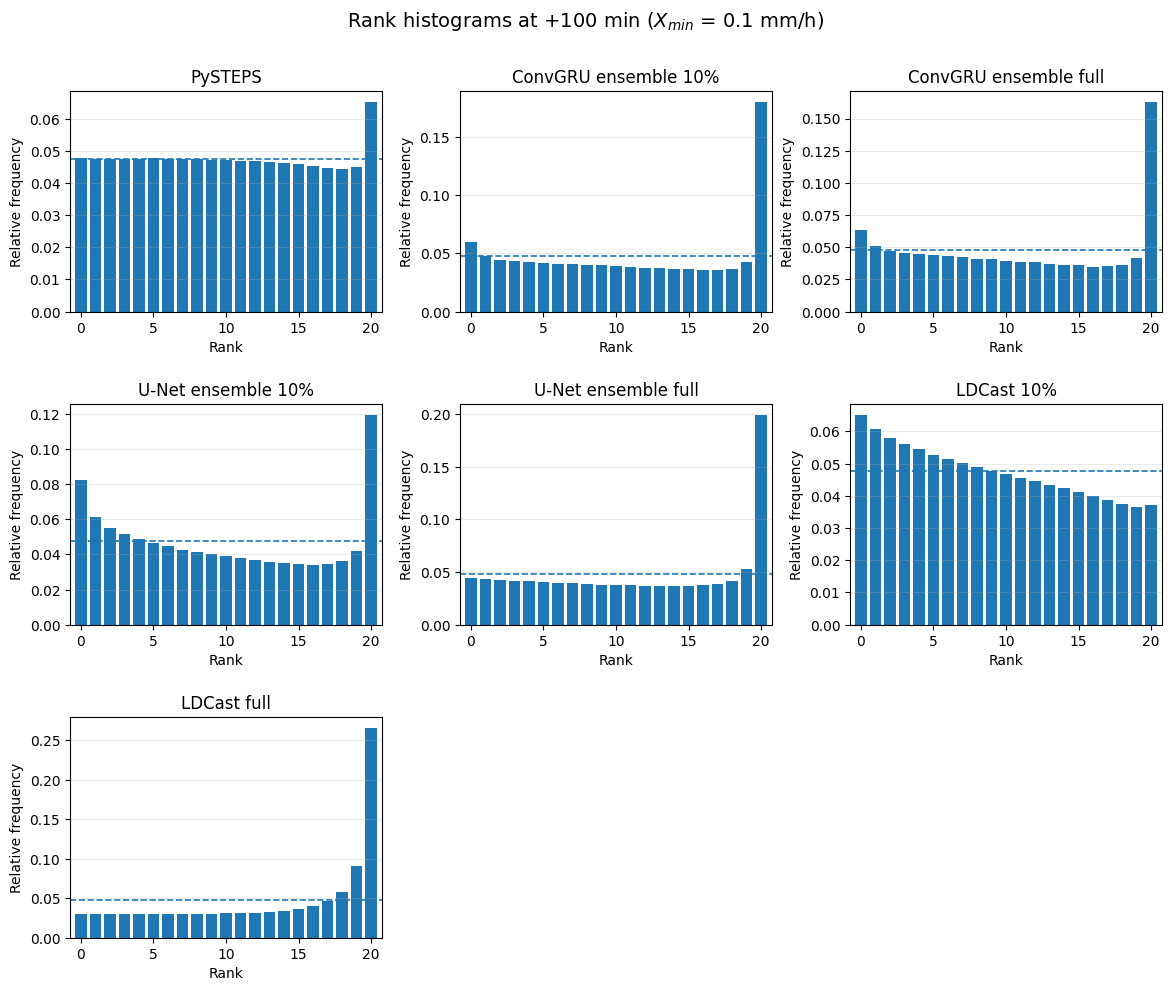

In [11]:
RANK_X_MIN = 0.1
RANK_LEADS = [5, 50, 100]

PROBABILISTIC_MODELS = [
    "PySTEPS",
    "ConvGRU ensemble 10%",
    "ConvGRU ensemble full",
    "U-Net ensemble 10%",
    "U-Net ensemble full",
    "LDCast 10%",
    "LDCast full",
]


def plot_rank_histograms(
    lead_time=50,
    x_min=RANK_X_MIN,
    filename=None,
):
    df = rank.copy()

    # ---------------------------------------------------------
    # Require the NEW PySTEPS-style rank-histogram definition.
    # ---------------------------------------------------------
    required_cols = {
        "model_label",
        "n_members",
        "rank_x_min_mm_h",
        "lead_time_min",
        "rank_bin",
        "relative_frequency",
        "expected_relative_frequency",
    }

    missing_cols = required_cols - set(df.columns)

    if missing_cols:
        raise RuntimeError(
            "Rank-histogram CSVs are not using the final definition.\n"
            f"Missing columns: {sorted(missing_cols)}\n\n"
            "Recompute rank histograms with the final metric code using "
            "PySTEPS verification.rankhist_* and X_min = 0.1 mm/h."
        )

    # Final thesis definition:
    # X_min = 0.1 mm/h.
    #
    # IMPORTANT:
    # This is NOT equivalent to filtering observations with obs >= 0.1.
    # PySTEPS rankhist excludes a pixel only when the observation and
    # all ensemble members are below X_min.
    df = df[
        np.isclose(
            df["rank_x_min_mm_h"],
            x_min,
        )
    ].copy()

    # Select requested lead time.
    df = df[
        df["lead_time_min"] == lead_time
    ].copy()

    if df.empty:
        raise RuntimeError(
            f"No rank-histogram rows found for "
            f"lead={lead_time} min, X_min={x_min} mm/h."
        )

    # ---------------------------------------------------------
    # Final inference should use 20 members for every
    # probabilistic model -> 21 rank bins.
    # ---------------------------------------------------------
    member_check = (
        df.groupby("model_label", observed=True)["n_members"]
        .unique()
    )

    print(f"\nRank histogram +{lead_time} min, X_min={x_min} mm/h")

    for label, members in member_check.items():
        print(f"  {label}: n_members={list(members)}")

        if len(members) != 1 or int(members[0]) != 20:
            raise RuntimeError(
                f"{label} does not use the final 20-member "
                f"ensemble: n_members={list(members)}"
            )

    # Make sure all final probabilistic models are present.
    labels_present = {
        str(x)
        for x in df["model_label"].dropna().unique()
    }

    missing_models = [
        label
        for label in PROBABILISTIC_MODELS
        if label not in labels_present
    ]

    if missing_models:
        raise RuntimeError(
            "Final rank-histogram metrics are still missing for:\n"
            + "\n".join(f"  - {m}" for m in missing_models)
            + "\n\nRecompute those models before making the final thesis figure."
        )

    # Keep thesis model order.
    labels = [
        label
        for label in PROBABILISTIC_MODELS
        if label in labels_present
    ]

    # ---------------------------------------------------------
    # Plot
    # ---------------------------------------------------------
    ncols = 3
    nrows = int(np.ceil(len(labels) / ncols))

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(12, 3.4 * nrows),
    )

    axes = np.asarray(axes).reshape(-1)

    for ax, label in zip(axes, labels):

        gg = (
            df[
                df["model_label"].astype(str)
                == label
            ]
            .sort_values("rank_bin")
        )

        if len(gg) != 21:
            raise RuntimeError(
                f"{label} at +{lead_time} min has "
                f"{len(gg)} rank bins; expected 21."
            )

        ax.bar(
            gg["rank_bin"],
            gg["relative_frequency"],
        )

        expected = float(
            gg["expected_relative_frequency"].iloc[0]
        )

        ax.axhline(
            expected,
            linestyle="--",
            linewidth=1.2,
            label="Expected uniform frequency",
        )

        ax.set_title(label)
        ax.set_xlabel("Rank")
        ax.set_ylabel("Relative frequency")

        # 20 members -> ranks 0,...,20.
        ax.set_xlim(-0.75, 20.75)
        ax.set_xticks([0, 5, 10, 15, 20])

        ax.grid(
            axis="y",
            alpha=0.25,
        )

    # Turn off unused panels.
    for ax in axes[len(labels):]:
        ax.axis("off")

    fig.suptitle(
        f"Rank histograms at +{lead_time} min "
        f"($X_{{min}}$ = {x_min:g} mm/h)",
        fontsize=14,
    )

    fig.subplots_adjust(
        left=0.07,
        right=0.98,
        top=0.90,
        bottom=0.07,
        hspace=0.42,
        wspace=0.25,
    )

    if filename is None:
        xmin_str = str(x_min).replace(".", "p")

        filename = (
            f"rank_histograms_xmin{xmin_str}_"
            f"lead{lead_time:03d}.png"
        )

    savefig(filename)
    plt.show()


# Generate all three diagnostics.
for lead in RANK_LEADS:
    plot_rank_histograms(
        lead_time=lead,
        x_min=RANK_X_MIN,
    )

Using window column: 'window_size_px'
Available windows: [np.int64(5), np.int64(10), np.int64(30), np.int64(60)]
Using threshold column: 'threshold_mm_h'
Available thresholds: [np.float64(0.1), np.float64(0.5), np.float64(1.0), np.float64(5.0), np.float64(30.0)]
Saved: /data/brussel/114/vsc11442/code/mlcast-ldcast/results/evaluation/test_2021_6hourly/figures_results/fss_by_lead.png


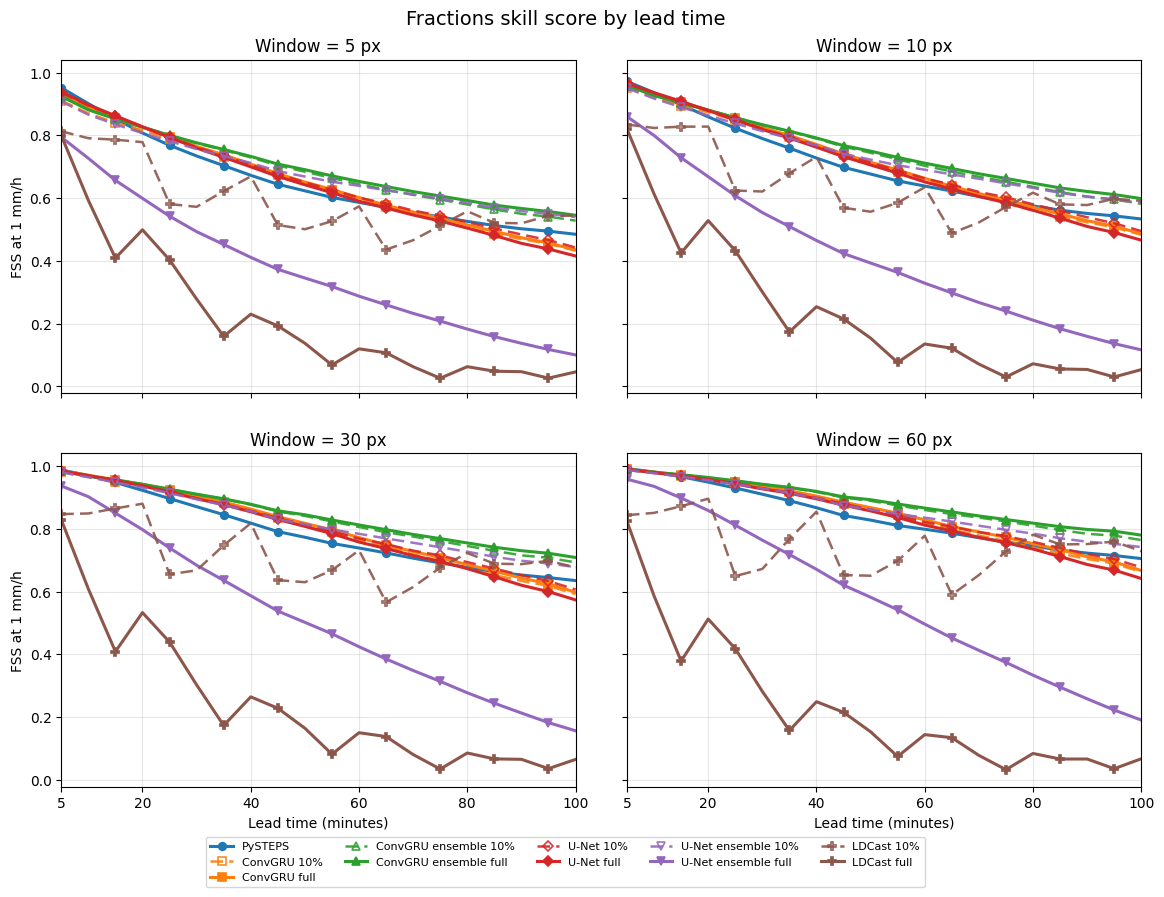

In [12]:
SELECTED_FSS_THRESHOLD = 1.0
SELECTED_WINDOWS = [5, 10, 30, 60]


def plot_fss_by_lead(filename="fss_by_lead.png"):
    df = add_lead_minutes(
        add_threshold_col(
            add_window_col(fss)
        )
    )
    # Thesis FSS uses the ensemble mean for probabilistic models.
    if "forecast_type" in df.columns:
        df = df[
            df["forecast_type"]
            == "deterministic_style"
        ].copy()
        
    fss_col = metric_col(df, ["fss", "FSS"])

    if "threshold_plot" not in df.columns:
        raise KeyError("No threshold column found in fss.csv")

    if "window_plot" not in df.columns:
        raise KeyError(
            "No window/neighbourhood column found in fss.csv"
        )

    # Keep the selected rain-rate threshold
    df = df[
        np.isclose(
            df["threshold_plot"],
            SELECTED_FSS_THRESHOLD,
        )
    ].copy()

    available_windows = sorted(
        df["window_plot"].dropna().unique()
    )

    windows = [
        w for w in SELECTED_WINDOWS
        if np.any(np.isclose(available_windows, w))
    ]

    if not windows:
        windows = available_windows[:4]

    # 2 × 2 thesis-friendly layout
    fig, axes = plt.subplots(
        2,
        2,
        figsize=(12, 9.2),
        sharex=True,
        sharey=True,
    )

    axes = axes.flatten()

    for i, window in enumerate(windows):
        ax = axes[i]

        dw = df[
            np.isclose(
                df["window_plot"],
                window,
            )
        ].copy()

        g = (
            dw.groupby(
                ["model_label", "lead_min_plot"],
                observed=True,
            )[fss_col]
            .mean()
            .reset_index()
        )

        for label in ordered_model_labels(g):
            gg = (
                g[
                    g["model_label"].astype(str)
                    == label
                ]
                .sort_values("lead_min_plot")
            )

            if gg.empty:
                continue

            ax.plot(
                gg["lead_min_plot"],
                gg[fss_col],
                label=label,
                **style_for(label),
            )

        ax.set_title(f"Window = {int(window)} px")
        ax.set_xticks(LEAD_TICKS)
        ax.set_xlim(5, 100)
        ax.grid(True, alpha=0.3)

        # Labels only on outer panels
        if i % 2 == 0:
            ax.set_ylabel(
                f"FSS at "
                f"{SELECTED_FSS_THRESHOLD:g} mm/h"
            )

        if i >= 2:
            ax.set_xlabel("Lead time (minutes)")

    # Hide unused panels
    for j in range(len(windows), len(axes)):
        axes[j].set_visible(False)

    # Collect legend entries from the first populated panel
    handles, labels = axes[0].get_legend_handles_labels()

    # Shared legend below all four panels
    fig.legend(
        handles,
        labels,
        loc="lower center",
        bbox_to_anchor=(0.5, 0.015),
        ncol=5,
        fontsize=8,
        frameon=True,
    )

    fig.suptitle(
        "Fractions skill score by lead time",
        fontsize=14,
        y=0.975,
    )

    # Reserve space for title and bottom legend
    fig.subplots_adjust(
        left=0.08,
        right=0.98,
        top=0.92,
        bottom=0.13,
        hspace=0.18,
        wspace=0.10,
    )

    savefig(filename)
    plt.show()


plot_fss_by_lead()

Saved: /data/brussel/114/vsc11442/code/mlcast-ldcast/results/evaluation/test_2021_6hourly/figures_results/reliability_diagrams.png


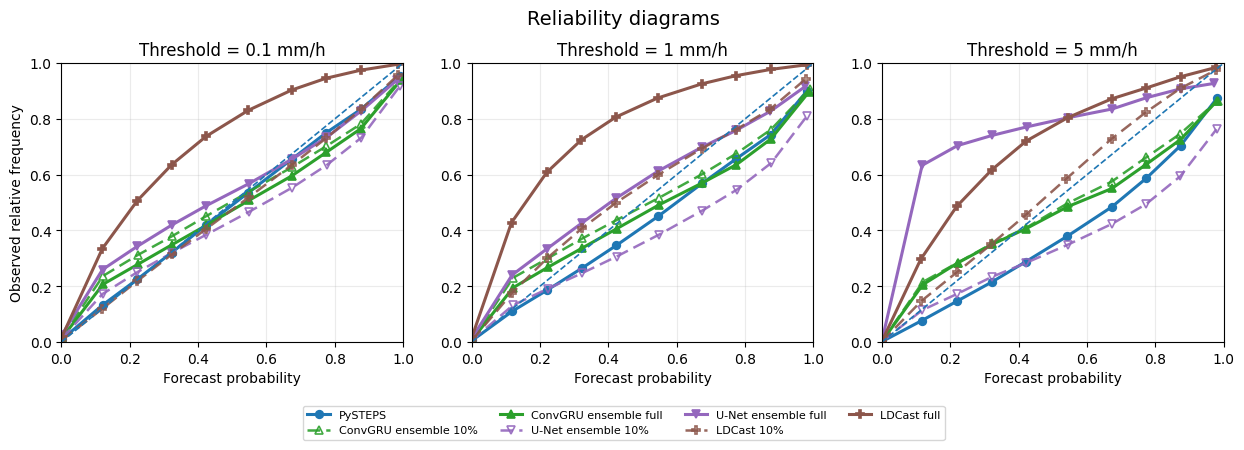

In [13]:
def plot_reliability(
    thresholds=(0.1, 1.0, 5.0),
    filename="reliability_diagrams.png",
):
    df = reliability.copy()

    fig, axes = plt.subplots(
        1,
        len(thresholds),
        figsize=(5.0 * len(thresholds), 4.5),
    )

    if len(thresholds) == 1:
        axes = [axes]

    for ax, threshold in zip(
        axes,
        thresholds,
    ):
        dth = df[
            np.isclose(
                df["threshold_mm_h"],
                threshold,
            )
        ].copy()

        for label in ordered_model_labels(dth):

            gg = dth[
                dth["model_label"].astype(str)
                == label
            ].copy()

            gg = gg[
                (gg["n"] > 0)
                & gg["mean_forecast_probability"].notna()
                & gg["observed_frequency"].notna()
            ]

            style = style_for(label)
            style.pop("markevery", None)
            
            ax.plot(
                gg["mean_forecast_probability"],
                gg["observed_frequency"],
                label=label,
                **style,
            )

        ax.plot(
            [0, 1],
            [0, 1],
            linestyle="--",
            linewidth=1.2,
        )

        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.set_title(
            f"Threshold = {threshold:g} mm/h"
        )
        ax.set_xlabel("Forecast probability")
        ax.grid(alpha=0.25)

    axes[0].set_ylabel(
        "Observed relative frequency"
    )

    handles, labels = (
        axes[-1]
        .get_legend_handles_labels()
    )
    
    fig.legend(
        handles,
        labels,
        loc="lower center",
        bbox_to_anchor=(0.5, 0.01),
        ncol=4,
        fontsize=8,
    )
    
    fig.suptitle(
        "Reliability diagrams",
        fontsize=14,
    )
    
    fig.subplots_adjust(
        bottom=0.24,
        top=0.86,
        wspace=0.20,
    )
    
    savefig(filename)
    plt.show()


plot_reliability()